In [17]:
from dotenv import load_dotenv
import os
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from pydantic import BaseModel
import operator


In [18]:
load_dotenv()

True

In [19]:
# Initialize the ChatGroq model
llm = ChatGroq(
    api_key=os.getenv("GROQ_API_KEY"),
    model_name = "llama-3.3-70b-versatile"
)

## Project 1: Cricket Stats (No LLM)

In [28]:
class BatsmanState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    bpb: float # balls per boundary
    boundary_percentage: float
    summary: str

In [29]:
def calculate_strike_rate(state: BatsmanState):
    sr = (state['runs'] / state['balls']) * 100

    return {'strike_rate': sr}

In [30]:
def calculate_ball_per_boundary(state: BatsmanState):
    bpb = state['balls'] / (state['fours'] + state['sixes'])
    return {'bpb': bpb}


In [31]:
def calculate_boundary_percentage(state: BatsmanState):
    bp = ((state['fours'] + state['sixes']) / state['balls']) * 100
    return {'boundary_percentage': bp}

In [32]:
def summary(state: BatsmanState):
    summary = f"The batsman scored {state['runs']} runs off {state['balls']} balls with a strike rate of {state['strike_rate']:.2f}. He hit {state['fours']} fours and {state['sixes']} sixes, resulting in a boundary percentage of {state['boundary_percentage']:.2f}% and a ball per boundary ratio of {state['bpb']:.2f}."
    return {'summary': summary}


In [33]:
# Build a graph

batsman_graph = StateGraph(BatsmanState)

batsman_graph.add_node("strike_rate", calculate_strike_rate)
batsman_graph.add_node("ball_per_boundary", calculate_ball_per_boundary)
batsman_graph.add_node("boundary_percentage", calculate_boundary_percentage)
batsman_graph.add_node("summary", summary)

# add edges to the graph
batsman_graph.add_edge(START, "strike_rate")
batsman_graph.add_edge(START, "ball_per_boundary")
batsman_graph.add_edge(START, "boundary_percentage")

batsman_graph.add_edge("strike_rate", "summary")
batsman_graph.add_edge("ball_per_boundary", "summary")
batsman_graph.add_edge("boundary_percentage", "summary")
batsman_graph.add_edge("summary", END)

# compile the graph
workflow = batsman_graph.compile()

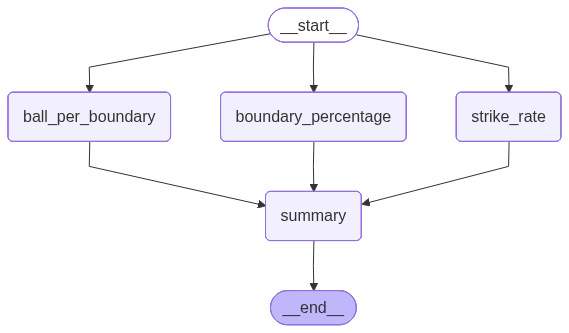

In [34]:
workflow

In [35]:
initial_state = {
    'runs': 120,
    'balls': 80,
    'fours': 10,
    'sixes': 5
}

workflow.invoke(initial_state)

{'runs': 120,
 'balls': 80,
 'fours': 10,
 'sixes': 5,
 'strike_rate': 150.0,
 'bpb': 5.333333333333333,
 'boundary_percentage': 18.75,
 'summary': 'The batsman scored 120 runs off 80 balls with a strike rate of 150.00. He hit 10 fours and 5 sixes, resulting in a boundary percentage of 18.75% and a ball per boundary ratio of 5.33.'}